In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env.py
%run run connect

2025-07-10 12:47:34,939::INFO::settings.py::Setting loglevel to INFO
2025-07-10 12:47:34,940::INFO::settings.py::Setting stores to {}
2025-07-10 12:47:34,940::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-07-10 12:47:34,941::INFO::settings.py::Setting database.misc.create_tables to True
2025-07-10 12:47:34,942::INFO::settings.py::Setting enable_python_native_blobs to True
2025-07-10 12:47:34,942::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2025-07-10 12:47:34,943::INFO::settings.py::Setting database.user to celia
2025-07-10 12:47:34,943::INFO::settings.py::Setting database.password to celia
2025-07-10 12:47:35,004::INFO::connection.py::Connected celia@128.178.51.167:3309
2025-07-10 12:47:35,018::INFO::table.py::could not log event in table ~log


Connecting celia@128.178.51.167:3309


2025-07-10 12:47:35,671::INFO::table.py::could not log event in table ~log
2025-07-10 12:47:35,671::INFO::table.py::could not log event in table ~log
2025-07-10 12:47:35,695::INFO::table.py::could not log event in table ~log
2025-07-10 12:47:35,695::INFO::table.py::could not log event in table ~log
2025-07-10 12:47:35,731::INFO::table.py::could not log event in table ~log
2025-07-10 12:47:35,731::INFO::table.py::could not log event in table ~log
2025-07-10 12:47:35,760::INFO::table.py::could not log event in table ~log
2025-07-10 12:47:35,760::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.vr4mice import SignalsPhotodiode, Collab, Labs
from vr4mice.schema.latency_tests import AllLatencies, SignalsPhotodiodeAligned

from vr4mice.analysis.latency_testing import get_signals, find_rising_edges, get_latency
import numpy as np 
import pandas as  pd
import matplotlib.pyplot as plt
import seaborn as sns
from vr4mice.analysis.analysis import style
from matplotlib.colors import ListedColormap 

style()

2025-07-10 12:47:35,824::INFO::table.py::could not log event in table ~log
2025-07-10 12:47:35,824::INFO::table.py::could not log event in table ~log


In [5]:
save_fig_path = "notebooks/Paper_figures/Figure_output/latency/"

In [6]:
# fetch latency data and transform into dataframe

mathis = (AllLatencies() & 'dataset LIKE "%Latencytest1%"').fetch( as_dict=True)
mathis_df = pd.concat([pd.DataFrame(d) for d in mathis])
mathis_df ["lab_id"] = "Mathis"
tolias = (AllLatencies() & 'dataset LIKE "%Latencytest2%"').fetch(as_dict=True)
tolias_df = pd.concat([pd.DataFrame(d) for d in tolias])
tolias_df ["lab_id"] = "Tolias"
niel = (AllLatencies() & 'dataset LIKE "%Latencytest3%"').fetch(as_dict=True)
neil_df = pd.concat([pd.DataFrame(d) for d in niel])
neil_df ["lab_id"] = "Niel"

latencies = pd.concat([mathis_df, tolias_df, neil_df])

In [7]:
mean_latencies =  latencies.groupby(["dataset", "lab_id"], as_index=False).mean()

In [8]:
mean_latencies [["dataset", "time_diff"]]

,dataset,time_diff
0,Latencytest1_2024-10-31_1,0.057624
1,Latencytest1_2024-10-31_2,0.052294
2,Latencytest1_2024-10-31_3,0.055488
3,Latencytest1_2024-10-31_4,0.057332
4,Latencytest1_2024-10-31_5,0.057414
5,Latencytest1_2024-10-31_6,0.056474
6,Latencytest2_2025-05-19_2,0.081183
7,Latencytest2_2025-05-19_3,0.084220
8,Latencytest2_2025-05-19_4,0.087179
9,Latencytest2_2025-05-19_5,0.074448


lab = Mathis mean (ms):  55.97584937966045 std: 9.15024485453672
lab = Tolias mean (ms):  80.85091598421178 std: 9.345266512532897
lab = Niel mean (ms):  59.70393234562562 std: 6.306178290000413


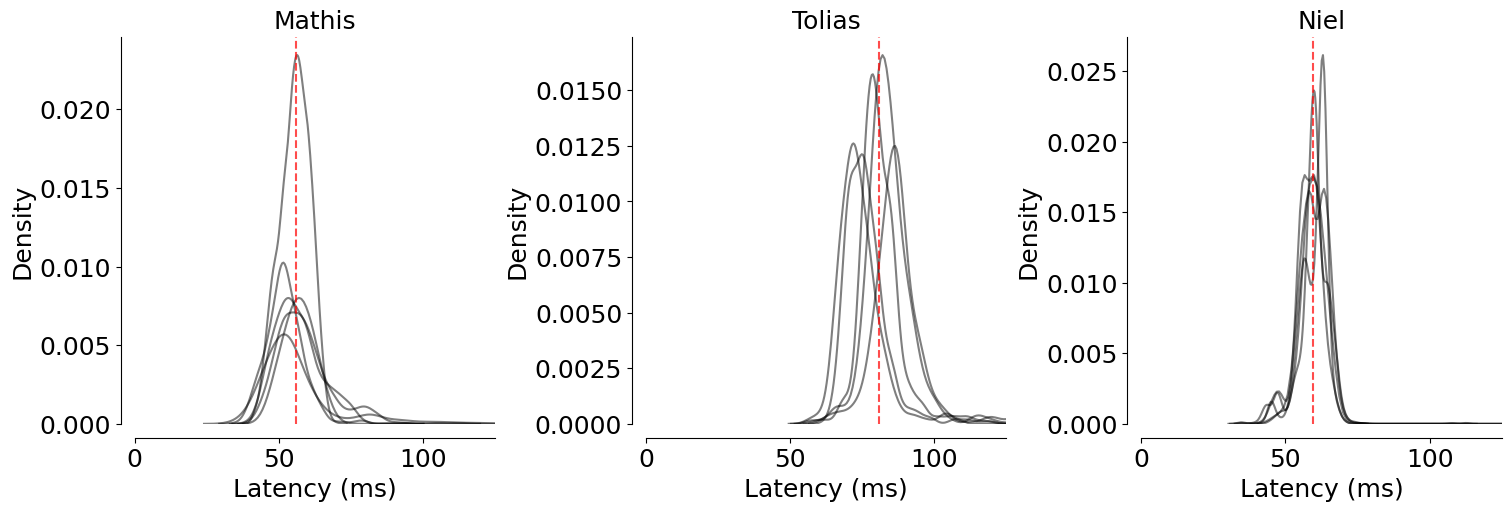

In [9]:
fig, ax = plt.subplots(1,3, figsize = (15,5), constrained_layout=True)
for i, lab in enumerate(latencies.lab_id.unique()):
    lab_latencies = latencies [latencies.lab_id == lab]
    g = sns.kdeplot(data=lab_latencies, x= lab_latencies.time_diff*1000, hue="dataset", palette=ListedColormap(['black']).colors, alpha=0.5, legend=False, ax=ax[i])
    ax[i].set_xlim(0,125)
    ax[i].set_xlabel("Latency (ms)")
    ax[i].axvline(np.mean(lab_latencies.time_diff*1000), c="red", linestyle="dashed", alpha = 0.7)
    print(f"lab = {lab} mean (ms): ", np.mean( lab_latencies.time_diff*1000), "std:", np.std( lab_latencies.time_diff*1000))

    sns.despine(offset=10)
    ax[i].set_title(lab)
plt.savefig(save_fig_path + "roundtrip_latency.svg")

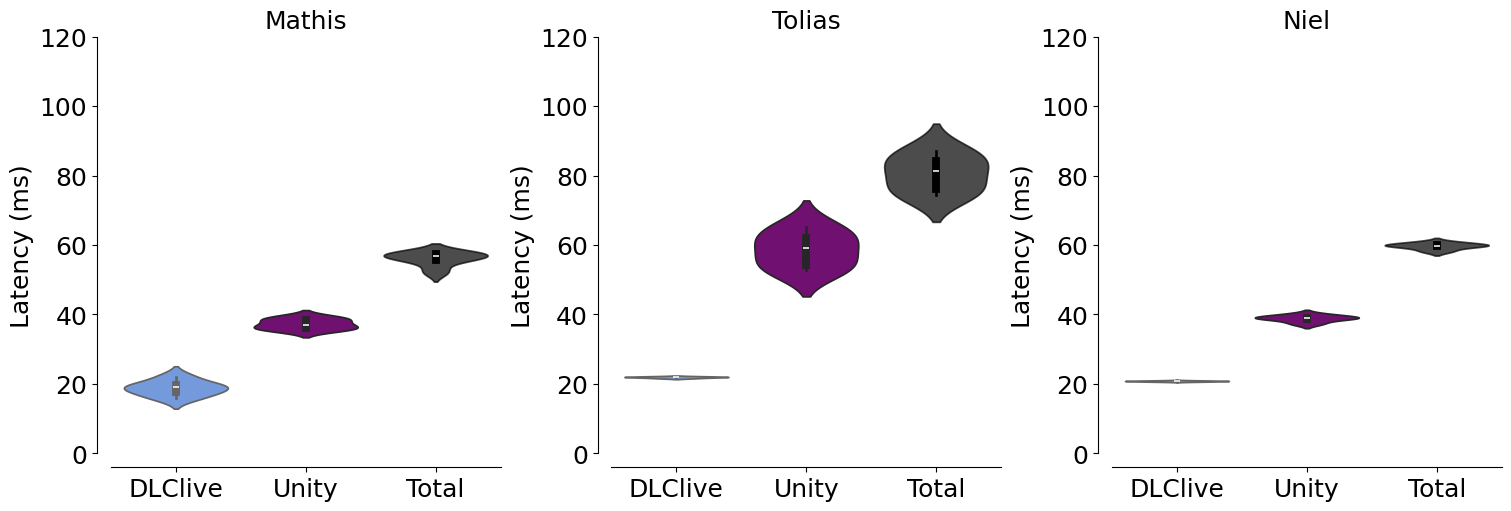

In [10]:
fig, ax = plt.subplots(1,3, figsize = (15,5), constrained_layout=True)
for i, lab in enumerate(mean_latencies.lab_id.unique()):
    lab_latencies = mean_latencies [mean_latencies.lab_id == lab]

    sns.violinplot(x=np.repeat("DLClive", len(lab_latencies ["time_diff"])), y=abs(lab_latencies ["frame_to_socket"])*1000, color="cornflowerblue", ax=ax[i])
    sns.violinplot(x=np.repeat("Unity", len(lab_latencies ["time_diff"])), y=(abs(lab_latencies ["time_diff"])*1000) - (abs(lab_latencies ["frame_to_socket"])*1000), color="purple", ax=ax[i])
    sns.violinplot(x=np.repeat("Total", len(lab_latencies ["time_diff"])), y=abs(lab_latencies ["time_diff"])*1000, color="black", alpha=0.7,ax=ax[i])

    ax[i].set_ylabel("Latency (ms)")
    ax[i].set_ylim(0,120)
    sns.despine(offset=10)
    ax[i].set_title(lab)
plt.savefig(save_fig_path + "mean_latencies.svg")

start_time 10.146146774291992


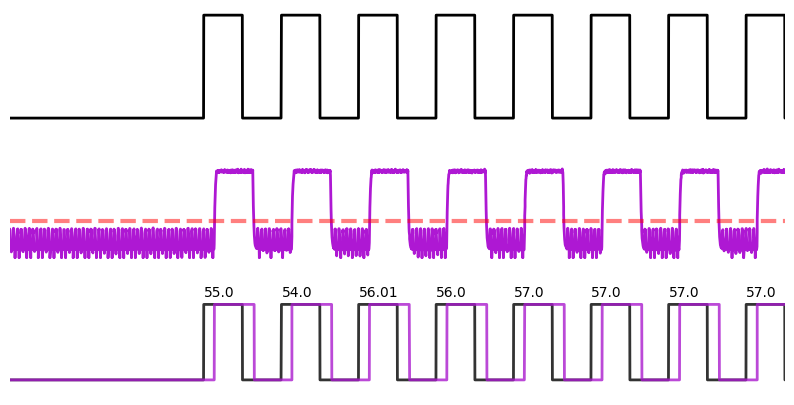

In [11]:
# This fecth call takes some time as the photodide is sampled at 1000 hz
df = pd.DataFrame((SignalsPhotodiodeAligned() & 'dataset =  "Latencytest1_2024-10-31_2"').fetch(as_dict=True)[0])
rising_edges_signal = find_rising_edges(df.time_stamp, df.signal_read)
rising_edges_photodiode = find_rising_edges(df.time_stamp, df.photodiode_read)
latencies = get_latency(rising_edges_signal, rising_edges_photodiode)

start_time = df.time_stamp[np.where(df.signal_read == 1)[0][0]]
print("start_time", start_time)

fig, ax = plt.subplots(3,1,figsize=(10,5))
ax[0].plot(df.time_stamp, df.signal_read,c="black",linewidth=2)


ax[1].plot(df.time_stamp, df.photodiode_raw_scaled, c="#AE18D3",linewidth=2)

ax[2].plot(df.time_stamp,  df.signal_read, c="black",linewidth=2,alpha=0.8)
ax[2].plot(df.time_stamp,  df.photodiode_read, c="#AA1BCE",linewidth=2,alpha=0.8)

for ft, td in zip(latencies.frame_time, latencies.time_diff):
    ax[2].annotate(round(td*1000, 2), (ft, 1.1))

ax[1].set_ylim(-0.2,1.3)

ax[1].axhline(0.3,c="red",linestyle="dashed",alpha=0.5, linewidth=3)
ax[2].set_ylim(-0.2,1.3)


sns.despine(offset=10)

for a in ax:
    a.axis('off')
    a.set_xlim(start_time-1,start_time+3)

plt.savefig(save_fig_path + "signal.svg")

In [12]:
mean_latencies

,dataset,lab_id,frame_time,time_diff,photodiode_time,frame_to_socket
0,Latencytest1_2024-10-31_1,Mathis,160.206761,0.057624,160.264385,0.022104
1,Latencytest1_2024-10-31_2,Mathis,183.545026,0.052294,183.597319,0.015869
2,Latencytest1_2024-10-31_3,Mathis,391.928782,0.055488,391.984271,0.019394
3,Latencytest1_2024-10-31_4,Mathis,176.912174,0.057332,176.969506,0.019602
4,Latencytest1_2024-10-31_5,Mathis,205.440877,0.057414,205.498290,0.018630
5,Latencytest1_2024-10-31_6,Mathis,150.832268,0.056474,150.888741,0.017312
6,Latencytest2_2025-05-19_2,Tolias,180.560032,0.081183,180.641215,0.022077
7,Latencytest2_2025-05-19_3,Tolias,214.032393,0.084220,214.116613,0.022139
8,Latencytest2_2025-05-19_4,Tolias,163.218385,0.087179,163.305564,0.021935
9,Latencytest2_2025-05-19_5,Tolias,165.315094,0.074448,165.389542,0.021643


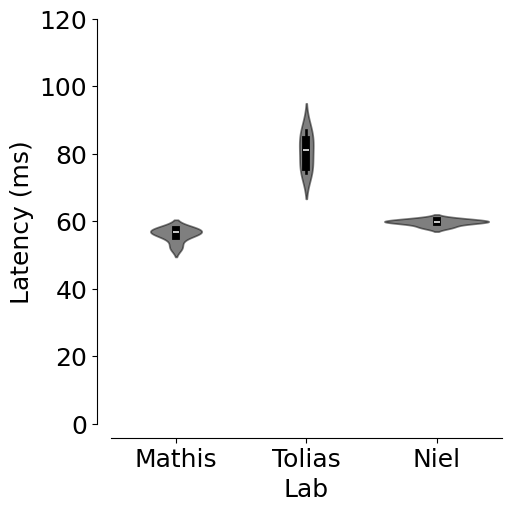

In [13]:
fig, ax = plt.subplots(1,1, figsize = (5,5), constrained_layout=True)

sns.violinplot(data=mean_latencies, x="lab_id", y=mean_latencies.time_diff*1000, color="black", ax=ax, alpha=0.5)
   
ax.set_ylabel("Latency (ms)")
ax.set_xlabel("Lab")
ax.set_ylim(0,120)
sns.despine(offset=10)

plt.savefig(save_fig_path + "mean_latencies_lab.svg")

In [14]:
mean_latencies.groupby("lab_id")["time_diff"].mean() * 1000, mean_latencies.groupby("lab_id")["time_diff"].sem() * 1000

(lab_id
 Mathis    56.104219
 Niel      59.703195
 Tolias    80.619879
 Name: time_diff, dtype: float64,
 lab_id
 Mathis    0.828018
 Niel      0.403628
 Tolias    2.398950
 Name: time_diff, dtype: float64)